In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import requests
from io import BytesIO
from tqdm import tqdm
import matplotlib.pyplot as plt
from itertools import combinations

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, VALID_METRICS
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

plt.rcParams["figure.figsize"] = (7, 4)

## Dataset Description

This notebook uses a supervised solar flare image dataset created from real Solar Dynamics Observatory (SDO) observations from the year **2014**.

The dataset was constructed from a larger solar event pipeline. First, flare events were selected using the **NOAA solar proton event list**. The year **2014** was chosen because it occurred during Solar Cycle 24, a period of strong solar activity. From that year, the strongest flare events were selected for this classification activity.

The original SDO/AIA data have a high observing cadence of approximately **12 seconds**. Because many consecutive images can look nearly identical at that cadence, the dataset was not created by keeping every available image. Instead, the data were **stratified and randomly sampled** at approximately **1-minute intervals** so that the final dataset would include a more useful and less repetitive set of examples.

For each selected flare event, the flare peak time was used to query the **Heliophysics Event Knowledgebase (HEK)**. HEK provided event metadata, including the flare start time, flare end time, and bounding box information for the solar event. These times were used to organize the data into three broad phases:

- **Pre-flare**
- **Flare**
- **Post-flare**

For this first KNN classification model, the labels are binary:

- `0` = non-flare image  
- `1` = flare image  

The HEK bounding box coordinates were transformed into image pixel coordinates using the FITS header and World Coordinate System (WCS) information. For each selected date and event, the metadata and coordinate information were saved as JSON files.

The corresponding FITS files were then downloaded from **JSOC**. Each FITS file contains the solar image data array and header metadata. The data arrays were used to create solar images, and the HEK bounding boxes were overlaid on the images to identify the flare or non-flare region. A **512 × 512 pixel cutout** was then created around the selected region.

Each final cutout was saved as a `.npy` array. These `.npy` files contain the numerical pixel values used for feature extraction in this notebook.

The final dataset contains:

- **2,378 total cutout images**
- **512 × 512 pixels per cutout**
- **Binary labels**
  - `0` = non-flare
  - `1` = flare
- **Data year:** 2014
- **Instrument/channel:** SDO/AIA 131 Å

## Visualizing the Solar Cutout Dataset

Before building the KNN model, we will first explore examples from the solar image dataset.

This section allows us to move through the dataset one image at a time. Each example shows two connected image views and the numerical data array associated with the same observation.

| Full-Disk Image with Annotation | 512 × 512 Cutout |
|---|---|
| Shows where the selected event region appears on the Sun. | Shows the smaller image region used for feature extraction. |

Below the images, the notebook also displays the cutout as a numerical data array. This helps show that each solar image is not just a picture. It is also a grid of pixel values that can be measured, summarized, and used as input for machine learning.

Interactive controls:

- **Previous / Next buttons** to move through the dataset
- **Image counter** showing which example is currently displayed
- **Image name** showing the filename for the selected observation
- **DataFrame preview** showing the numerical pixel values from the selected cutout

This section connects the physical solar image to the machine learning input:

**Full-disk solar image → annotated region → 512 × 512 cutout → numerical array → feature vector**

In [5]:
# Load the URL list
url_csv = "https://www.fitsflow.org/fits2asdf/nrao_supervised_ml/cutouts/images/solar_image_viewer_urls.csv"
url_df = pd.read_csv(url_csv)

index = 0

out = widgets.Output()

prev_button = widgets.Button(description="Previous")
next_button = widgets.Button(description="Next")

button_box = widgets.HBox(
    [prev_button, next_button],
    layout=widgets.Layout(justify_content="center")
)

def get_image_name(url):
    return url.split("/")[-1]

def show_row(i):
    with out:
        clear_output(wait=True)

        row = url_df.iloc[i]

        full_url = row["full_annotated_url"]
        cutout_url = row["cutout_url"]
        data_url = row["data_csv_url"]

        image_name = get_image_name(full_url)

        # Pull CSV into Python as dataframe
        data_df = pd.read_csv(data_url, header=None)

        display(HTML(f"""
        <div style="text-align:center; font-family:Arial, sans-serif;">
            <h2>Solar Image Viewer</h2>
            <p>Viewing image {i + 1} of {len(url_df)}</p>
            <p><b>Image name:</b> {image_name}</p>
        </div>

        <div style="
            display:grid;
            grid-template-columns:1fr 1fr;
            gap:25px;
            align-items:start;
            margin-top:20px;
        ">

            <div style="text-align:center;">
                <h3>Full Annotated Image</h3>
                <img src="{full_url}" style="width:75%; border:1px solid #ccc;">
            </div>

            <div style="text-align:center;">
                <h3>Cutout Image</h3>
                <img src="{cutout_url}" style="width:75%; border:1px solid #ccc;">
            </div>

        </div>

        <hr>

        <div style="text-align:center; font-family:Arial, sans-serif;">
            <h3>CSV Data Array</h3>
        </div>
        """))

        display(data_df)

def previous_clicked(b):
    global index
    if index > 0:
        index -= 1
        show_row(index)

def next_clicked(b):
    global index
    if index < len(url_df) - 1:
        index += 1
        show_row(index)

prev_button.on_click(previous_clicked)
next_button.on_click(next_clicked)

display(button_box)
display(out)

show_row(index)

Output()

# Guided Example: K-Nearest Neighbors (KNN) for Solar Flare Image Classification

This notebook demonstrates a simple end-to-end **KNN classification** workflow:

1. **Solar flare image cutouts** (512×512 `.npy` arrays)  
2. **Feature extraction** (turn each cutout into a feature vector)  
3. **Standardization** (scale the feature matrix)  
4. **KNN classification**  
5. **Confusion matrix interpretation**

---

## Big idea

KNN does not “learn” parameters like linear regression.

Instead, it stores labeled training points in **feature space** and classifies new samples by looking at the **k nearest** training points.

## 1) Load image filenames and labels

The label file contains one row for each solar cutout.

Each row includes:

- `filename`: the original FITS filename
- `label`: the class label  
  - `0` = non-flare  
  - `1` = flare  

The `.npy` cutout files use the same base filename as the FITS files, but with `.npy` instead of `.fits`.

In [8]:
# Store the public URL for the image label CSV file.
labels_url = "https://www.fitsflow.org/fits2asdf/nrao_supervised_ml/image_labels/image_labels.csv"

# Read the image label CSV file into a pandas DataFrame.
labels_df = pd.read_csv(labels_url)

# Store the base URL where the .npy cutout arrays are located.
npy_base_url = "https://www.fitsflow.org/fits2asdf/nrao_supervised_ml/cutouts/data/fits/cutouts_npy/"

# Create the .npy filename by replacing the .fits extension with .npy.
labels_df["npy_filename"] = labels_df["filename"].str.replace(".fits", ".npy", regex=False)

# Create the full public URL for each .npy cutout file.
labels_df["npy_url"] = npy_base_url + labels_df["npy_filename"]

# Display the first five rows of the updated label table.
labels_df.head()

,filename,label,npy_filename,npy_url
0,aia.lev1_euv_12s.2014-01-07T150810Z.131.image_...,0,aia.lev1_euv_12s.2014-01-07T150810Z.131.image_...,https://www.fitsflow.org/fits2asdf/nrao_superv...
1,aia.lev1_euv_12s.2014-01-07T151146Z.131.image_...,0,aia.lev1_euv_12s.2014-01-07T151146Z.131.image_...,https://www.fitsflow.org/fits2asdf/nrao_superv...
2,aia.lev1_euv_12s.2014-01-07T151158Z.131.image_...,0,aia.lev1_euv_12s.2014-01-07T151158Z.131.image_...,https://www.fitsflow.org/fits2asdf/nrao_superv...
3,aia.lev1_euv_12s.2014-01-07T151334Z.131.image_...,0,aia.lev1_euv_12s.2014-01-07T151334Z.131.image_...,https://www.fitsflow.org/fits2asdf/nrao_superv...
4,aia.lev1_euv_12s.2014-01-07T151658Z.131.image_...,0,aia.lev1_euv_12s.2014-01-07T151658Z.131.image_...,https://www.fitsflow.org/fits2asdf/nrao_superv...


## 2) Feature Extraction

Each 512 × 512 solar cutout is converted into a **feature vector**.

A feature vector is a list of numerical measurements that summarizes one image. Instead of giving the KNN model all 262,144 pixel values from the cutout, we first describe each cutout using a smaller set of interpretable features.

KNN compares images by distance in feature space. These features help place each solar cutout into that space using measurements related to brightness, contrast, texture, and edge structure.

For each cutout, we calculate:

- **Mean intensity**  
  Measures the average brightness of the cutout. Flare regions may have different overall brightness levels than non-flare regions.

- **Standard deviation of intensity**  
  Measures how spread out the pixel values are. A higher standard deviation means the image has stronger contrast between darker and brighter regions.

- **Maximum intensity**  
  Measures the brightest pixel in the cutout. This can help identify very bright localized emission, although it may be less useful if the images are already normalized.

- **95th percentile intensity**  
  Measures the brightness level near the top of the pixel-value distribution without depending only on one brightest pixel. This is useful because it captures strong bright regions while being less sensitive to a single extreme value.

- **Fraction of bright pixels**  
  Measures how much of the cutout is bright by calculating the fraction of pixels above the 95th percentile threshold. This helps describe whether the bright region is small and concentrated or spread across more of the cutout.

- **Entropy**  
  Measures the complexity or texture of the image. Images with more varied pixel patterns tend to have higher entropy.

- **Gradient magnitude statistics**  
  Measure how quickly pixel values change across the image. These features help describe edges, boundaries, loops, and other structures in the solar cutout.

Together, these features turn each solar image into a numerical point that KNN can compare with other labeled examples.

In [9]:
# Define a function to estimate the entropy of one image.
def image_entropy(img, bins=64, eps=1e-12):

    # Create a histogram of all pixel values in the image.
    hist, _ = np.histogram(img.ravel(), bins=bins, density=True)

    # Add a small number to avoid taking log2(0).
    p = hist + eps

    # Normalize the histogram so it behaves like a probability distribution.
    p = p / p.sum()

    # Compute and return the entropy value.
    return float(-np.sum(p * np.log2(p)))


# Define a function to calculate gradient magnitude statistics.
def gradient_magnitude_stats(img):

    # Calculate the image gradient in the y and x directions.
    gy, gx = np.gradient(img)

    # Combine the x and y gradients into a gradient magnitude image.
    mag = np.sqrt(gx**2 + gy**2)

    # Return the mean, standard deviation, and maximum gradient magnitude.
    return float(mag.mean()), float(mag.std()), float(mag.max())


# Define a function to extract one feature vector from one image.
def extract_features(img):

    # Replace NaN values with zero so calculations do not fail.
    img = np.nan_to_num(img)

    # Calculate the average pixel intensity.
    mean_intensity = float(img.mean())

    # Calculate the standard deviation of pixel intensity.
    std_intensity = float(img.std())

    # Calculate the maximum pixel intensity.
    max_intensity = float(img.max())

    # Calculate the 95th percentile pixel intensity.
    p95_intensity = float(np.percentile(img, 95))

    # Calculate the fraction of pixels greater than or equal to the 95th percentile.
    bright_pixel_fraction = float((img >= p95_intensity).mean())

    # Calculate the entropy of the image.
    entropy = image_entropy(img)

    # Calculate gradient magnitude summary statistics.
    grad_mean, grad_std, grad_max = gradient_magnitude_stats(img)

    # Store all calculated features in one NumPy array.
    feature_vector = np.array([
        mean_intensity,
        std_intensity,
        max_intensity,
        p95_intensity,
        bright_pixel_fraction,
        entropy,
        grad_mean,
        grad_std,
        grad_max
    ])

    # Return the feature vector for this image.
    return feature_vector

### Build the Feature Matrix

Next, we loop through every labeled cutout, load the matching `.npy` array, extract its feature vector, and store the result.

At the end of this step:

- `feature_vectors` stores the input data for the model.
- `labels` stores the correct class labels.
- `filenames` stores the original filenames.
- `failed_files` stores any files that could not be loaded.

In [10]:
# Create an empty list to store one feature vector per image.
feature_vectors = []

# Create an empty list to store one label per image.
labels = []

# Create an empty list to store one filename per image.
filenames = []

# Create an empty list to store any files that fail to load.
failed_files = []

# Loop through every row in the label table.
for idx, row in tqdm(labels_df.iterrows(), total=len(labels_df)):

    # Get the original FITS filename for this row.
    filename = row["filename"]

    # Get the class label for this row.
    label = row["label"]

    # Get the .npy cutout URL for this row.
    npy_url = row["npy_url"]

    # Try to download and process the cutout.
    try:

        # Download the .npy cutout file from its URL.
        response = requests.get(npy_url, timeout=30)

        # Stop the code if the file download failed.
        response.raise_for_status()

        # Load the .npy cutout into a NumPy array.
        img = np.load(BytesIO(response.content))

        # Extract the feature vector from the cutout.
        x = extract_features(img)

        # Add the feature vector to the feature vector list.
        feature_vectors.append(x)

        # Add the matching label to the label list.
        labels.append(label)

        # Add the matching filename to the filename list.
        filenames.append(filename)

    # Handle any file that fails to download or process.
    except Exception as e:

        # Print the filename that failed.
        print(f"Failed: {filename}")

        # Print the error message.
        print(e)

        # Add the failed filename to the failed file list.
        failed_files.append(filename)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2378/2378 [14:37<00:00,  2.71it/s]


## 3) Build X and y

After extracting features, we organize the dataset into the standard supervised learning format:

- **X**: the feature matrix with shape `(n_samples, n_features)`
- **y**: the label vector with shape `(n_samples,)`

Each row of **X** represents one solar cutout.  
Each value in **y** is the correct label for the matching row in **X**.

For this dataset:

- `0` = non-flare
- `1` = flare

In [11]:
# Stack all individual feature vectors into one feature matrix.
X = np.vstack(feature_vectors)

# Convert the label list into a NumPy label vector.
y = np.array(labels)

# Convert the filename list into a NumPy array.
filenames = np.array(filenames)

# Define the names of the features in the same order they appear in X.
feature_names = [
    "mean_intensity",
    "std_intensity",
    "max_intensity",
    "p95_intensity",
    "bright_pixel_fraction",
    "entropy",
    "grad_mean",
    "grad_std",
    "grad_max"
]

# Create a readable DataFrame from the feature matrix.
features_df = pd.DataFrame(X, columns=feature_names)

# Add the label column to the feature table.
features_df["label"] = y

# Add the filename column to the feature table.
features_df["filename"] = filenames

# Display the first five rows of the feature table.
features_df.head()

,mean_intensity,std_intensity,max_intensity,p95_intensity,bright_pixel_fraction,entropy,grad_mean,grad_std,grad_max,label,filename
0,0.096371,0.051014,1.0,0.193878,0.052151,3.469406,0.027352,0.016146,0.253310,0,aia.lev1_euv_12s.2014-01-07T150810Z.131.image_...
1,0.106075,0.056148,1.0,0.213483,0.052803,3.602077,0.030187,0.017864,0.297806,0,aia.lev1_euv_12s.2014-01-07T151146Z.131.image_...
2,0.108535,0.057373,1.0,0.218391,0.052208,3.611122,0.030877,0.018304,0.298076,0,aia.lev1_euv_12s.2014-01-07T151158Z.131.image_...
3,0.121034,0.063770,1.0,0.243590,0.052307,3.778676,0.034367,0.020427,0.499918,0,aia.lev1_euv_12s.2014-01-07T151334Z.131.image_...
4,0.078519,0.041467,1.0,0.158333,0.051678,3.195378,0.022358,0.013442,0.474525,0,aia.lev1_euv_12s.2014-01-07T151658Z.131.image_...


In [12]:
# Save the full feature table as a CSV file.
features_df.to_csv("solar_flare_knn_feature_table.csv", index=False)

# Save the machine-learning-ready arrays as a compressed NumPy file.
np.savez(
    "solar_flare_knn_features.npz",
    X=X,
    y=y,
    filenames=filenames,
    feature_names=np.array(feature_names)
)

# Print the shape of the feature matrix.
print("X shape:", X.shape)

# Print the shape of the label vector.
print("y shape:", y.shape)

# Print the number of filenames saved.
print("Number of filenames:", len(filenames))

# Print the number of files that failed during processing.
print("Number of failed files:", len(failed_files))

# Count how many examples belong to each class.
unique, counts = np.unique(y, return_counts=True)

# Print the number of examples for each label.
for label, count in zip(unique, counts):
    print(f"Label {label}: {count}")

X shape: (2378, 9)
y shape: (2378,)
Number of filenames: 2378
Number of failed files: 0
Label 0: 1780
Label 1: 598


## 4) Visualizing Feature Space with Scatterplots

KNN classifies each cutout by comparing its position to other labeled examples in **feature space**.

Each point in the scatterplots below represents one solar cutout. The color of the point shows the known class label:

- **Non-flare**
- **Flare**

The full KNN model uses all of the extracted features together, which means the data live in a higher-dimensional feature space. Since we cannot directly draw a 9-dimensional space, we visualize the data by plotting two features at a time.

For this section, we selected six features for visualization:

- `mean_intensity`
- `std_intensity`
- `p95_intensity`
- `bright_pixel_fraction`
- `entropy`
- `grad_mean`

These features were chosen because they are easier to interpret visually and describe different properties of the solar cutouts:

- **Mean intensity** describes average brightness.
- **Standard deviation** describes contrast.
- **95th percentile intensity** describes strong bright regions without depending only on one extreme pixel.
- **Bright pixel fraction** describes how much of the cutout is relatively bright.
- **Entropy** describes texture or complexity.
- **Gradient mean** describes average edge strength.

We excluded some features from this scatterplot section because they were less useful for visualization:

- `max_intensity` was excluded because many cutouts are normalized and have maximum values close to 1.0, which creates vertical or horizontal lines in scatterplots.
- `grad_std` and `grad_max` were excluded to keep the visualization easier to read. They are still useful features for the KNN model, but they can make the scatterplot grid more crowded.

This means the scatterplots are for **visual exploration**, not a complete replacement for the model. The KNN model can still use all 9 features, while the plots help us understand some two-dimensional views of the feature space.

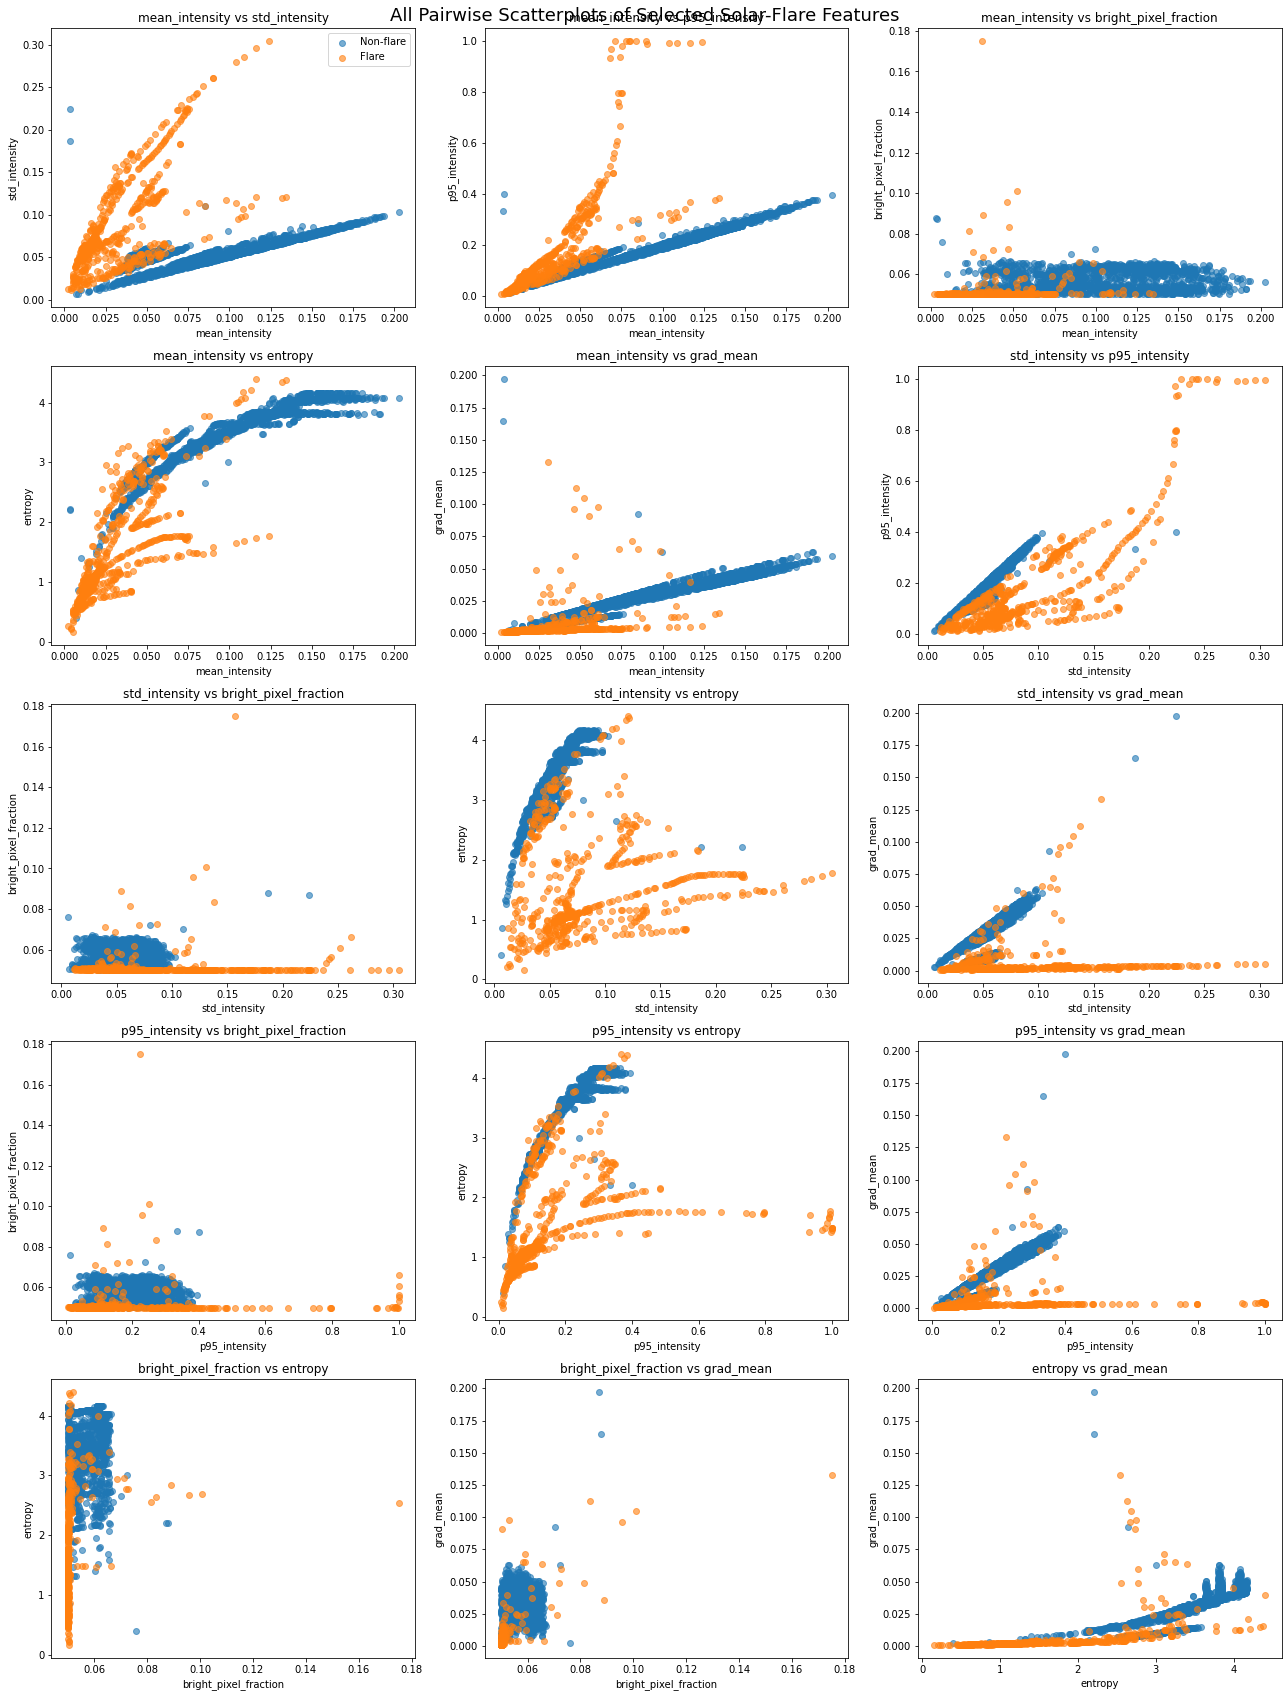

In [13]:
# Select the features that will be compared in the scatterplot grid.
scatter_features = [
    "mean_intensity",
    "std_intensity",
    "p95_intensity",
    "bright_pixel_fraction",
    "entropy",
    "grad_mean"
]

# Create every unique pair of selected features.
pairs = list(combinations(scatter_features, 2))

# Create a 5-row by 3-column grid for the 15 scatterplots.
fig, axes = plt.subplots(5, 3, figsize=(18, 24))

# Flatten the grid of axes so we can loop through them easily.
axes = axes.flatten()

# Loop through each subplot and each feature pair.
for ax, (xcol, ycol) in zip(axes, pairs):

    # Loop through the two class labels.
    for label, name in [(0, "Non-flare"), (1, "Flare")]:

        # Select only the rows with the current label.
        subset = features_df[features_df["label"] == label]

        # Plot the selected feature pair for the current class.
        ax.scatter(
            subset[xcol],
            subset[ycol],
            alpha=0.6,
            label=name
        )

    # Label the x-axis with the selected feature name.
    ax.set_xlabel(xcol)

    # Label the y-axis with the selected feature name.
    ax.set_ylabel(ycol)

    # Add a title showing which two features are being compared.
    ax.set_title(f"{xcol} vs {ycol}")

# Add the legend to the first subplot only.
axes[0].legend()

# Add a title for the full figure.
plt.suptitle("All Pairwise Scatterplots of Selected Solar-Flare Features", fontsize=18)

# Adjust layout so subplot labels do not overlap.
plt.tight_layout()

# Display the scatterplot grid.
plt.show()

## 5) Train/test Split

We split the dataset into a training set and a testing set.

- The **training set** is used to fit the KNN model.
- The **testing set** is used to evaluate the model on data it did not see during training.

We use `stratify=y` so that the flare and non-flare class proportions stay similar in both sets.

In [14]:
# Create an array of row numbers so we can track which samples are in the test set.
indices = np.arange(len(y))

# Split the feature matrix and labels into training and testing sets.
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X,
    y,
    indices,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Print the shape of the training feature matrix.
print("X_train:", X_train.shape)

# Print the shape of the testing feature matrix.
print("X_test:", X_test.shape)

# Print the shape of the training label vector.
print("y_train:", y_train.shape)

# Print the shape of the testing label vector.
print("y_test:", y_test.shape)

X_train: (1783, 9)
X_test: (595, 9)
y_train: (1783,)
y_test: (595,)


## 6) Standardization

KNN uses **distance**, so scaling matters. We standardize features using z-scores:

$
z = \frac{x - \mu}{\sigma}
$


In [15]:
# Create a StandardScaler object.
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data.
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing data using the scaler fitted on the training data.
X_test_scaled = scaler.transform(X_test)

## 7) KNN Implementation

KNN classifies a test point by looking at the labels of its nearest training points.

The value of `k` tells the model how many neighbors to use.

### Distance Metrics in KNN

KNN classifies a point by finding the training examples closest to it. The word “closest” depends on the distance metric.

In this notebook, we use the default scikit-learn distance behavior. By default, `KNeighborsClassifier` uses the Minkowski distance with `p = 2`, which is equivalent to Euclidean distance.

Common distance options include:

| Metric | Meaning | When it may be useful |
|---|---|---|
| `euclidean` | Straight-line distance | Good default for continuous numerical features |
| `manhattan` | Sum of absolute differences | Useful when changes along each feature axis add separately |
| `minkowski` | General distance formula controlled by `p` | `p=1` gives Manhattan, `p=2` gives Euclidean |
| `chebyshev` | Largest single-coordinate difference | Useful when the largest feature difference matters most |
| `cosine` | Measures angle/direction rather than magnitude | Useful when relative pattern matters more than size |

For this lesson, we use Euclidean distance because it matches the hand-calculation version of KNN.

In [50]:
# Print all distance metrics available for brute-force nearest-neighbor search.
print(VALID_METRICS["brute"])
print("----------------------------------------")

['cityblock', 'cosine', 'euclidean', 'haversine', 'l2', 'l1', 'manhattan', 'precomputed', 'nan_euclidean', 'braycurtis', 'canberra', 'chebyshev', 'correlation', 'cosine', 'dice', 'hamming', 'jaccard', 'kulsinski', 'mahalanobis', 'matching', 'minkowski', 'rogerstanimoto', 'russellrao', 'seuclidean', 'sokalmichener', 'sokalsneath', 'sqeuclidean', 'yule', 'wminkowski']
----------------------------------------


### Connecting 2D Euclidean Distance to Multi-Dimensional KNN

When we calculated KNN by hand, we used the Euclidean distance formula for two features:

$$
d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}
$$

That formula works when each point has two coordinates:

$$
(x, y)
$$

In this notebook, each solar cutout has more than two features. Each cutout becomes one point in a 9-dimensional feature space:

$$
[\mathrm{mean},\ \mathrm{std},\ \mathrm{max},\ \mathrm{p95},\ \mathrm{bright\ fraction},\ \mathrm{entropy},\ \mathrm{grad\ mean},\ \mathrm{grad\ std},\ \mathrm{grad\ max}]
$$

KNN uses the same distance idea, but it extends the formula to include all features:

$$
d = \sqrt{
(f_{1,\mathrm{test}} - f_{1,\mathrm{train}})^2 +
(f_{2,\mathrm{test}} - f_{2,\mathrm{train}})^2 +
\cdots +
(f_{9,\mathrm{test}} - f_{9,\mathrm{train}})^2
}
$$

Each feature contributes to the distance between two cutouts. The closest training examples are the ones with the smallest distances.

For example, if `k = 5`, the model finds the five closest training cutouts. The majority label among those five neighbors becomes the predicted class for the test cutout.

In [29]:
# Set the number of nearest neighbors.
k = 5 # try 3, 7

# Create the KNN classifier using Euclidean distance.
knn = KNeighborsClassifier(
    n_neighbors=k,
    metric="euclidean" # try "manhattan", "minkowski", or "chebyshev"
)

# Train the KNN classifier using the standardized training data.
knn.fit(X_train_scaled, y_train)

# Predict labels for the standardized testing data.
y_pred = knn.predict(X_test_scaled)

# Print the metric used by this model.
print("Metric:", knn.metric)

Metric: euclidean


## 8) Confusion Matrix Interpretation

Binary mapping:

- `0` = non-flare
- `1` = flare

For this notebook:

- **Positive** = flare
- **Negative** = non-flare

Sklearn confusion matrix format:

$$
\begin{bmatrix}
TN & FP \\
FN & TP
\end{bmatrix}
$$

## Confusion Matrix and Accuracy

After the KNN model makes predictions, we compare the predicted labels to the true labels.

The confusion matrix shows four types of results:

| Term | Meaning |
|---|---|
| **True Positive (TP)** | The image was a flare, and the model predicted flare. |
| **True Negative (TN)** | The image was non-flare, and the model predicted non-flare. |
| **False Positive (FP)** | The image was non-flare, but the model predicted flare. |
| **False Negative (FN)** | The image was a flare, but the model predicted non-flare. |

[[442   3]
 [ 18 132]]


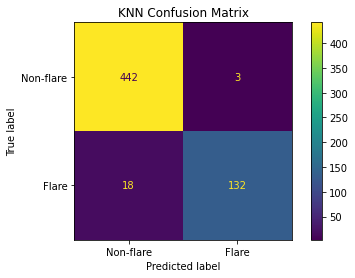

-----------------------


In [51]:
# Display the confusion matrix as a plot.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Non-flare", "Flare"]
)

# Add a title to the confusion matrix plot.
plt.title("KNN Confusion Matrix")

# Print the confusion matrix as a numerical array.
print(confusion_matrix(y_test, y_pred))

# Show the plot.
plt.show()

print("-----------------------")

### Evaluation Metrics

After the model makes predictions, we compare the predicted labels to the true labels. The classification report summarizes how well the model performed for each class.

In this notebook:

- `0` = non-flare
- `1` = flare

The main measurements are **precision**, **recall**, **F1-score**, **support**, **accuracy**, **macro average**, and **weighted average**.

---

#### Precision

Precision answers the question:

**When the model predicts a class, how often is it correct?**

For the flare class:

$$
\mathrm{Precision} = \frac{TP}{TP + FP}
$$

For the non-flare class:

$$
\mathrm{Precision}_{nonflare} = \frac{TN}{TN + FN}
$$

Precision is important when we want to know how trustworthy a positive prediction is. For example, high flare precision means that when the model predicts “flare,” it is usually correct.

---

#### Recall

Recall answers the question:

**Of all the true examples of a class, how many did the model find?**

For the flare class:

$$
\mathrm{Recall} = \frac{TP}{TP + FN}
$$

For the non-flare class:

$$
\mathrm{Recall}_{nonflare} = \frac{TN}{TN + FP}
$$

Recall is important when missing a class matters. For solar flare classification, flare recall tells us how many actual flare images the model successfully identified.

---

#### F1-Score

The F1-score combines precision and recall into one number.

$$
F_1 = 2 \times \frac{\mathrm{Precision} \times \mathrm{Recall}}{\mathrm{Precision} + \mathrm{Recall}}
$$

The F1-score is useful when we want a balance between precision and recall. A high F1-score means the model is doing well at both finding the class and avoiding incorrect predictions.

---

#### Support

Support is the number of true examples for each class in the test set.

For this notebook:

$$
\mathrm{Support}_{nonflare} = TN + FP
$$

$$
\mathrm{Support}_{flare} = TP + FN
$$

Support is important because it tells us how many test examples were used to calculate the metrics for each class.

---

#### Accuracy

Accuracy tells us the fraction of all test examples that were classified correctly.

$$
\mathrm{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

Accuracy is useful as an overall score, but it can hide class-specific behavior. That is why we also look at precision, recall, F1-score, and the confusion matrix.

---

#### Macro Average

The macro average calculates the metric for each class and then takes a simple average.

For example, macro precision is:

$$
\mathrm{Macro\ Precision} = \frac{\mathrm{Precision}_{nonflare} + \mathrm{Precision}_{flare}}{2}
$$

Macro average treats each class equally, even if one class has more examples than the other.

---

#### Weighted Average

The weighted average calculates the metric for each class, but weights each class by its support.

For example, weighted precision is:

$$
\mathrm{Weighted\ Precision} =
\frac{
(\mathrm{Precision}_{nonflare} \times \mathrm{Support}_{nonflare}) +
(\mathrm{Precision}_{flare} \times \mathrm{Support}_{flare})
}{
\mathrm{Support}_{nonflare} + \mathrm{Support}_{flare}
}
$$

Weighted average is useful when the dataset has more examples of one class than another. In this notebook, there are more non-flare examples than flare examples, so the weighted average gives more influence to the non-flare class.

---

The machine learning model creates the predictions. These metrics are then calculated from the predictions, the true labels, and the confusion matrix.

In [48]:
# Values from the confusion matrix:
# [[TN, FP],
#  [FN, TP]]

# Calculate the confusion matrix from the true and predicted labels.
cm = confusion_matrix(y_test, y_pred)

# Extract TN, FP, FN, and TP from the confusion matrix.
TN, FP, FN, TP = cm.ravel()

# -----------------------
# Class 0: Non-flare
# -----------------------

precision_nonflare = TN / (TN + FN)
recall_nonflare = TN / (TN + FP)
f1_nonflare = 2 * (precision_nonflare * recall_nonflare) / (precision_nonflare + recall_nonflare)
support_nonflare = TN + FP

# -----------------------
# Class 1: Flare
# -----------------------

precision_flare = TP / (TP + FP)
recall_flare = TP / (TP + FN)
f1_flare = 2 * (precision_flare * recall_flare) / (precision_flare + recall_flare)
support_flare = TP + FN

# -----------------------
# Accuracy
# -----------------------

accuracy = (TP + TN) / (TP + TN + FP + FN)
total_support = TP + TN + FP + FN

# -----------------------
# Macro averages
# Simple average across classes
# -----------------------

macro_precision = (precision_nonflare + precision_flare) / 2
macro_recall = (recall_nonflare + recall_flare) / 2
macro_f1 = (f1_nonflare + f1_flare) / 2

# -----------------------
# Weighted averages
# Average weighted by class size/support
# -----------------------

weighted_precision = (
    (precision_nonflare * support_nonflare) +
    (precision_flare * support_flare)
) / total_support

weighted_recall = (
    (recall_nonflare * support_nonflare) +
    (recall_flare * support_flare)
) / total_support

weighted_f1 = (
    (f1_nonflare * support_nonflare) +
    (f1_flare * support_flare)
) / total_support

# -----------------------
# Print results
# -----------------------

print("TN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)

print("-----------------------")

print("Non-flare precision:", precision_nonflare)
print("Non-flare recall:", recall_nonflare)
print("Non-flare F1:", f1_nonflare)
print("Non-flare support:", support_nonflare)

print("-----------------------")

print("Flare precision:", precision_flare)
print("Flare recall:", recall_flare)
print("Flare F1:", f1_flare)
print("Flare support:", support_flare)

print("-----------------------")

print("Accuracy:", accuracy)
print("Total support:", total_support)

print("-----------------------")

print("Macro precision:", macro_precision)
print("Macro recall:", macro_recall)
print("Macro F1:", macro_f1)

print("-----------------------")

print("Weighted precision:", weighted_precision)
print("Weighted recall:", weighted_recall)
print("Weighted F1:", weighted_f1)

TN: 442
FP: 3
FN: 18
TP: 132
-----------------------
Non-flare precision: 0.9608695652173913
Non-flare recall: 0.9932584269662922
Non-flare F1: 0.9767955801104974
Non-flare support: 445
-----------------------
Flare precision: 0.9777777777777777
Flare recall: 0.88
Flare F1: 0.9263157894736842
Flare support: 150
-----------------------
Accuracy: 0.9647058823529412
Total support: 595
-----------------------
Macro precision: 0.9693236714975846
Macro recall: 0.9366292134831461
Macro F1: 0.9515556847920907
-----------------------
Weighted precision: 0.9651321398124466
Weighted recall: 0.9647058823529412
Weighted F1: 0.9640695824709646


In [46]:
# Print the full classification report.
print(classification_report(y_test, y_pred))


print("-----------------------")

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       445
           1       0.98      0.88      0.93       150

    accuracy                           0.96       595
   macro avg       0.97      0.94      0.95       595
weighted avg       0.97      0.96      0.96       595

-----------------------


## 9) Visualizing Test Points in Feature Space

The confusion matrix tells us how many test samples were classified correctly or incorrectly.  
Now we will look at **where those test samples appear in feature space**.

In this plot:

- The faded background points are the **training examples**.
- The larger circle markers are **test examples that KNN classified correctly**.
- The larger X markers are **test examples that KNN classified incorrectly**.

This helps us connect the model results back to the idea of distance. If a test point lands near many examples from the wrong class, KNN may misclassify it.

For this visualization, we use only two features:

- `mean_intensity`
- `std_intensity`

The full KNN model uses all 9 extracted features, but this two-feature plot gives us a simple visual way to understand where some test points landed.

In [18]:
# Create a DataFrame for the test samples.
test_points_df = features_df.iloc[idx_test].copy()

# Add the model prediction for each test sample.
test_points_df["predicted_label"] = y_pred

# Add whether each prediction was correct.
test_points_df["correct"] = test_points_df["label"] == test_points_df["predicted_label"]

# Display the first few test points.
test_points_df.head()

,mean_intensity,std_intensity,max_intensity,p95_intensity,bright_pixel_fraction,entropy,grad_mean,grad_std,grad_max,label,filename,predicted_label,correct
2189,0.015690,0.066688,1.0,0.064091,0.050014,1.041461,0.001333,0.005207,0.127245,1,aia.lev1_euv_12s.2014-09-10T200022Z.131.image_...,1,True
64,0.120767,0.063048,1.0,0.243590,0.050182,3.772998,0.034402,0.020610,0.389763,0,aia.lev1_euv_12s.2014-01-07T161146Z.131.image_...,0,True
1235,0.079422,0.044386,1.0,0.162162,0.053391,3.312775,0.029340,0.017351,0.473021,0,aia.lev1_euv_12s.2014-02-25T025722Z.131.image_...,0,True
913,0.123853,0.062805,1.0,0.228571,0.065845,3.750789,0.036873,0.021569,0.385780,0,aia.lev1_euv_12s.2014-02-20T115546Z.131.image_...,0,True
858,0.131944,0.066153,1.0,0.246154,0.063202,3.961095,0.039243,0.022705,0.288025,0,aia.lev1_euv_12s.2014-02-20T105534Z.131.image_...,0,True


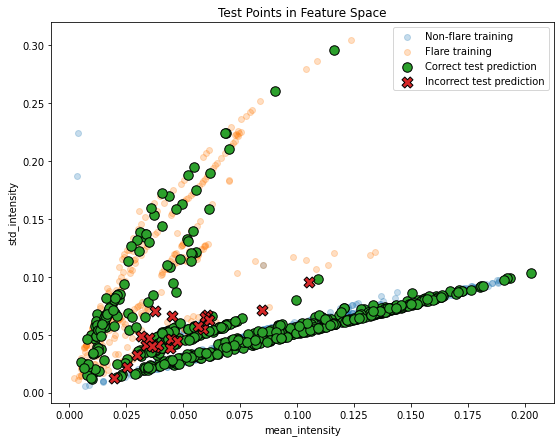

In [19]:
# Choose two features to plot.
x_feature = "mean_intensity"
y_feature = "std_intensity"

# Create a DataFrame for the training samples.
train_df = features_df.iloc[idx_train]

# Create the plot.
plt.figure(figsize=(9, 7))

# Plot all training points in the background.
for label, name in [(0, "Non-flare training"), (1, "Flare training")]:
    
    # Select training samples with the current label.
    train_subset = train_df[train_df["label"] == label]
    
    # Plot the training points.
    plt.scatter(
        train_subset[x_feature],
        train_subset[y_feature],
        alpha=0.25,
        label=name
    )

# Select correctly classified test points.
correct_test = test_points_df[test_points_df["correct"] == True]

# Select incorrectly classified test points.
incorrect_test = test_points_df[test_points_df["correct"] == False]

# Plot correctly classified test points.
plt.scatter(
    correct_test[x_feature],
    correct_test[y_feature],
    marker="o",
    s=90,
    edgecolor="black",
    label="Correct test prediction"
)

# Plot incorrectly classified test points.
plt.scatter(
    incorrect_test[x_feature],
    incorrect_test[y_feature],
    marker="X",
    s=120,
    edgecolor="black",
    label="Incorrect test prediction"
)

# Label the x-axis.
plt.xlabel(x_feature)

# Label the y-axis.
plt.ylabel(y_feature)

# Add a title.
plt.title("Test Points in Feature Space")

# Add a legend.
plt.legend()

# Show the plot.
plt.show()

## 10) Student wrap-up questions

1. What does each solar image become before the computer can use it for machine learning?

2. Why do we turn an image into numbers before using KNN?

3. In KNN, what does it mean to find the “nearest neighbors”?

4. What math formula did we use to measure how close two points are?

5. What does the value of **k** tell the model to do?

6. Why do we split the data into a training set and a test set?

7. What does accuracy tell us about the model?

8. If the model makes a mistake, what does that tell us about machine learning?
